<a href="https://colab.research.google.com/github/abhishekanand04/ML-Unsupervised-and-RecSys/blob/unsupervised/Time_Series_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (20,8)

In [ ]:
!gdown 1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg


Downloading...
From: https://drive.google.com/uc?id=1-pOuGRd8zuAUKBll-1xkr7_867NwoWHg
To: /content/mobilesales.xlsx
100% 13.7k/13.7k [00:00<00:00, 25.8MB/s]


NameError: name 'mobile_sales' is not defined

<Axes: xlabel='DATE'>

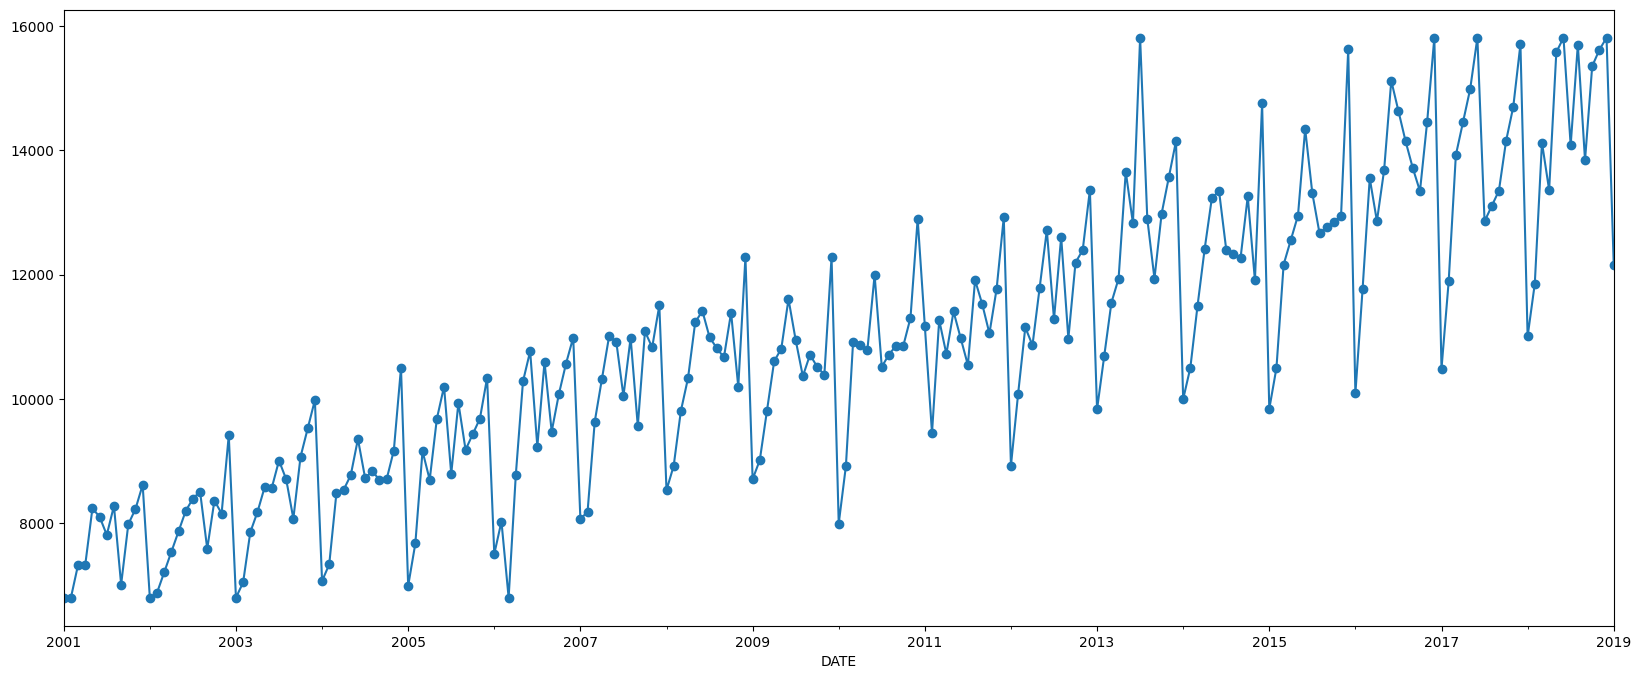

In [ ]:
mobile_sales = pd.read_excel('/content/mobilesales.xlsx')
# set index
mobile_sales.set_index('DATE', inplace=True)
# linear interpolation
mobile_sales.Sales = mobile_sales.Sales.interpolate(method='linear')
# anomalies - clip quantiles
mobile_sales.Sales = mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.98), lower=mobile_sales.Sales.quantile(0.02))
# plot
mobile_sales.Sales.plot(style='-o')

In [ ]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape

)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


train_max_date = mobile_sales.index[-12]

In [ ]:
train_x = mobile_sales.loc[mobile_sales.index < mobile_sales.index[-12]].copy()
test_x = mobile_sales.loc[mobile_sales.index >= mobile_sales.index[-12]].copy()

## What models do you know ?

In [ ]:
model = SARIMAX(train_x.Sales, order=(3, 1, 3), seasonal_order=(1,1,1,12))
model = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
test_x['pred'] = model.forecast(steps=12)

<Axes: xlabel='DATE'>

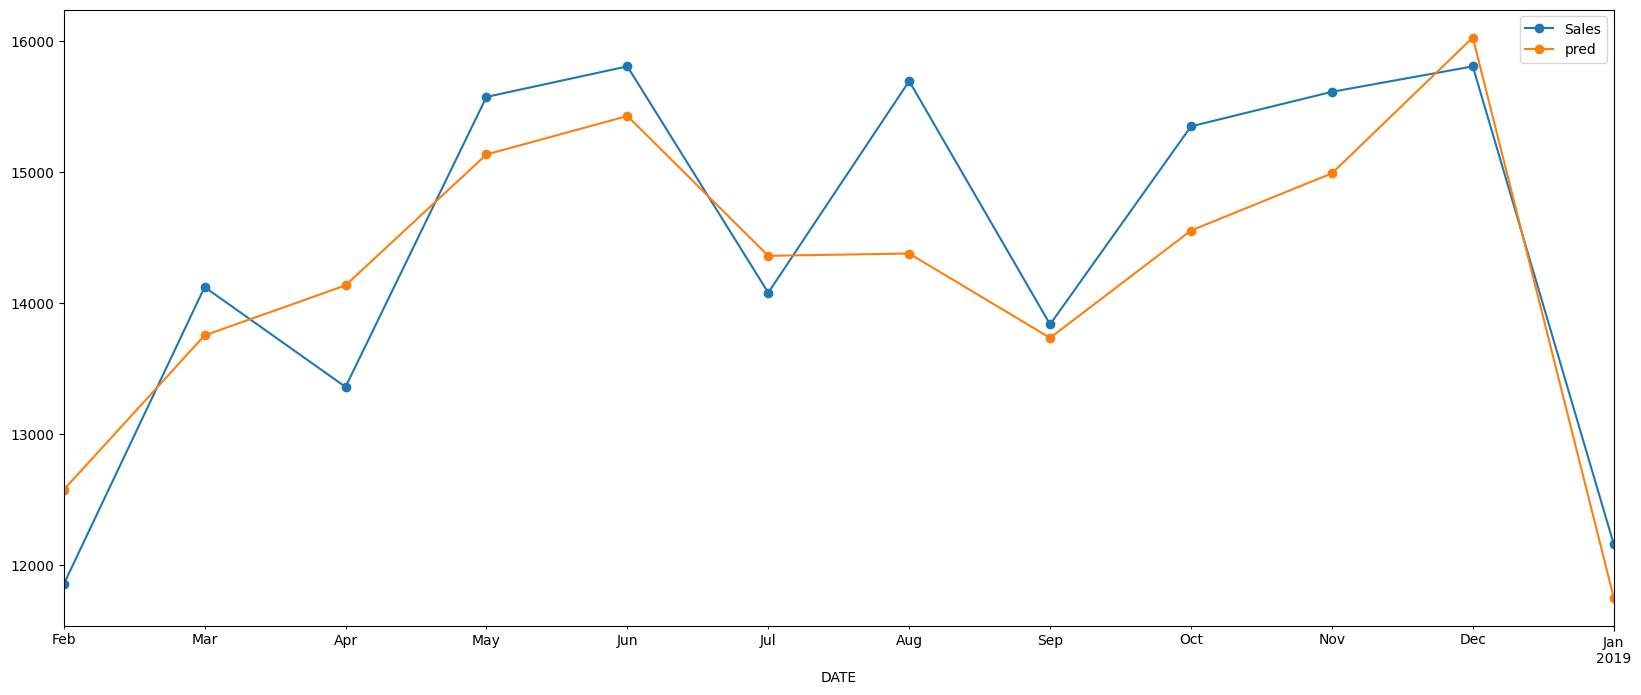

In [ ]:
test_x.plot(style='-o')

In [ ]:
performance(test_x['Sales'], test_x['pred'])

MAE : 536.465
RMSE : 623.233
MAPE: 0.037


## Confidence Interval

In [ ]:
conf  = model.get_forecast(steps = 12).conf_int(alpha = 0.15)

In [ ]:
conf.columns = ['lower','upper']

In [ ]:
test_x[['lower', 'upper']] = conf

In [ ]:
test_x

,Sales,pred,lower,upper
DATE,,,,
2018-02-01,11852.0,12574.194103,11423.428586,13724.959620
2018-03-01,14123.0,13753.825599,12567.053919,14940.597280
2018-04-01,13360.0,14136.205103,12944.037962,15328.372244
2018-05-01,15576.0,15136.279681,13939.887522,16332.671840
2018-06-01,15809.4,15430.324896,14233.524416,16627.125376
2018-07-01,14080.0,14362.090157,13163.782391,15560.397923
2018-08-01,15697.0,14379.407132,13178.388536,15580.425728
2018-09-01,13838.0,13734.718480,12533.443353,14935.993606
2018-10-01,15351.0,14555.045239,13351.890148,15758.200330


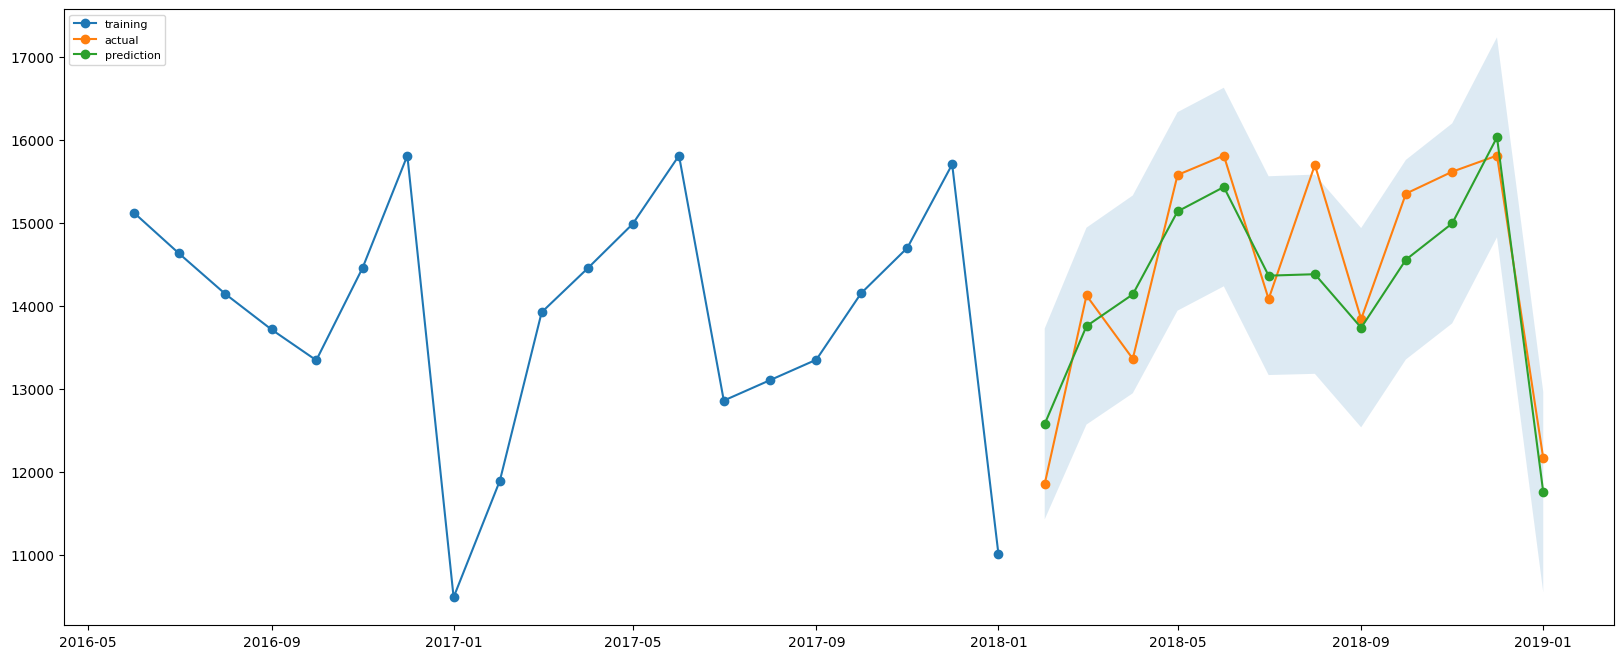

In [ ]:
plt.plot(train_x['Sales'][-20:], '-o', label='training')
plt.plot(test_x['Sales'], '-o', label='actual')
plt.plot(test_x['pred'], '-o', label='prediction')

plt.fill_between(
    test_x.index,
    test_x['lower'],
    test_x['upper'],
    alpha=0.15
)

plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
from IPython.display import Image
Image(url='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/007/752/original/illustration_of_change_point_detectopn_via_sliding-window.gif?1658421673')

## Optional

In [ ]:
!pip install ruptures


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.0 MB/s eta 0:00:00


In [ ]:
import ruptures as rpt

In [ ]:
signal = train_x.Sales.values

In [ ]:
# detection
algo = rpt.Pelt(model="rbf").fit(signal)

In [ ]:
changepoints = algo.predict(pen=5)

In [ ]:
changepoints

[65, 135, 205]

In [ ]:
def plot_changepoints(signal, changepoints):
  for cp in changepoints:
    plt.axvline(x=cp, color='#FA8072')
  plt.plot(signal, '-*', label='signal')

  start = 0
  trends = np.array([])
  for i in changepoints:
    x = np.arange(start, i)
    y = signal[start:i]
    l1 = np.polyfit(x, y, deg=1)
    trend = x*l1[0] + l1[1]
    trends = np.append(trends, trend)
    start = i

  plt.plot(trends, label='trend')
  plt.legend()
  plt.show()

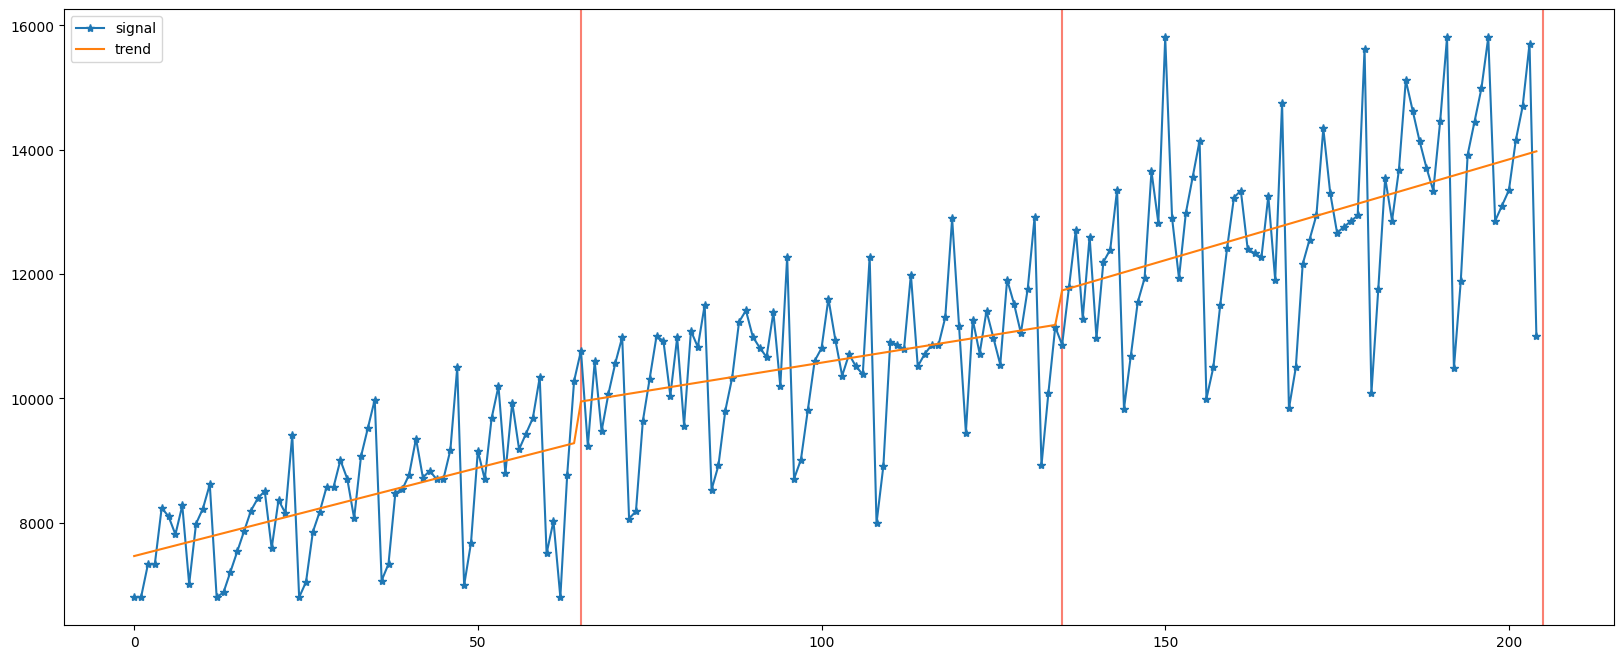

In [ ]:
plot_changepoints(signal, changepoints)


## Break - 7 mins

## Change Point from scratch

In [ ]:
signal = train_x.Sales

In [ ]:
window = 60

In [ ]:
def get_slope(y):
  return np.polyfit(np.arange(len(y)), y, deg=1)[0]

In [ ]:
condition = abs(signal.rolling(window).apply(get_slope).diff()) > 8

In [ ]:
changepoints  = signal.loc[condition].index

In [ ]:
temp = signal.reset_index()

In [ ]:
changepoints = temp.loc[temp['DATE'].isin(changepoints)].index.tolist()

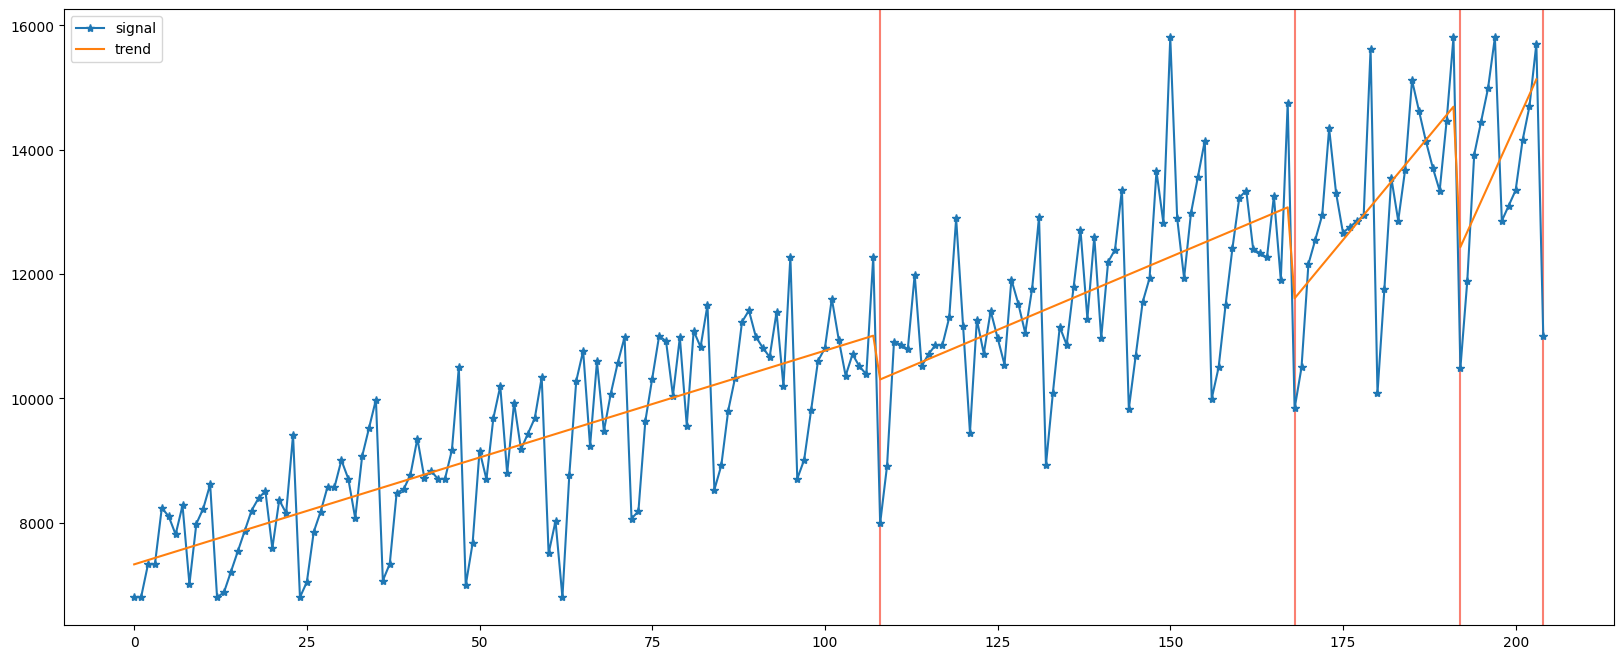

In [ ]:
plot_changepoints(signal.values, changepoints)


## SARIMAX - X In sarimax

In [ ]:
!gdown 16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta


Downloading...
From: https://drive.google.com/uc?id=16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta
To: /content/rest_vis.csv
100% 13.1k/13.1k [00:00<00:00, 24.4MB/s]


Xotica - food chain

In [ ]:
df = pd.read_csv('/content/rest_vis.csv')
df.head()

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [ ]:
df.isna().sum()


,0
date,0
weekday,0
holiday,0
total,39


In [ ]:
df1 = df.copy()


In [ ]:
df.dropna(inplace = True)


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date',inplace = True)
df.head(5)

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0


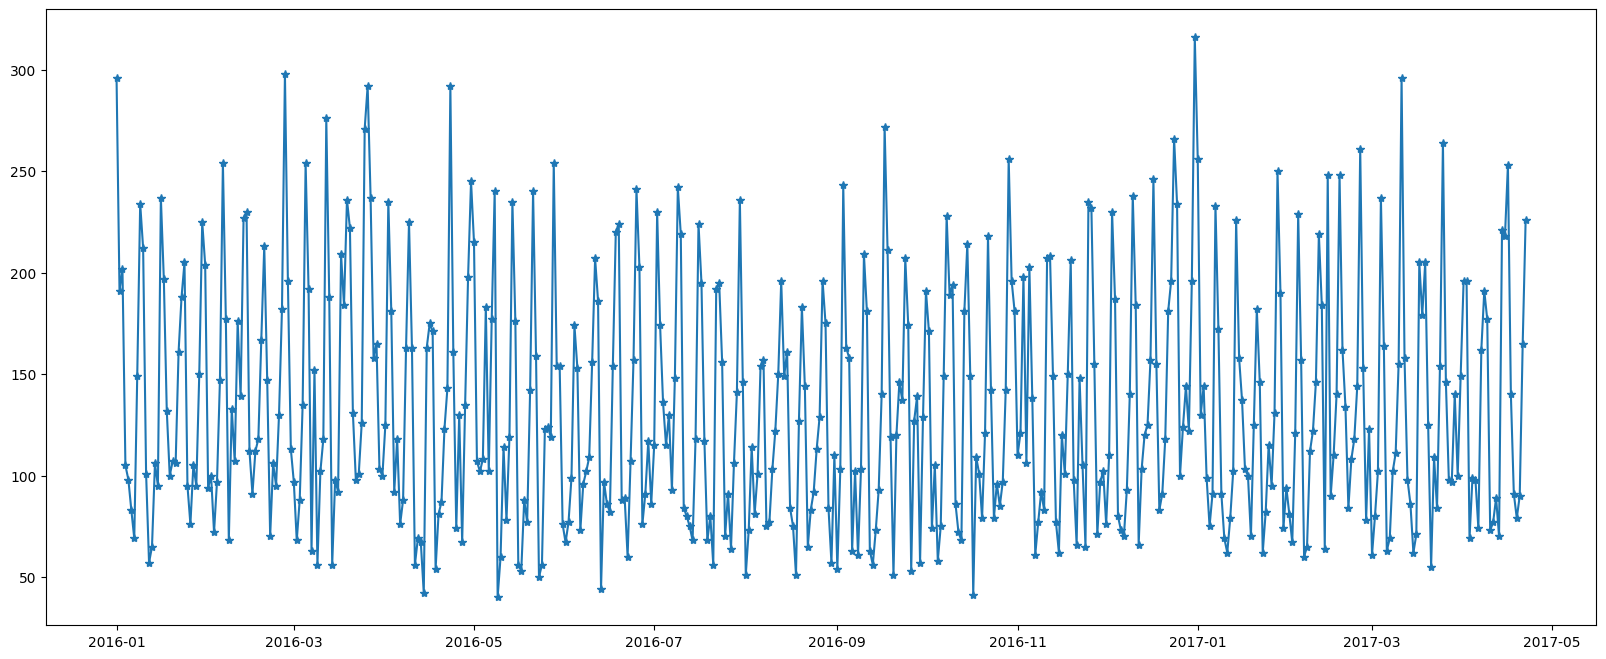

In [ ]:
# Lets take a look at our time series plot
plt.plot(df.index, df['total'], '-*')
plt.show()

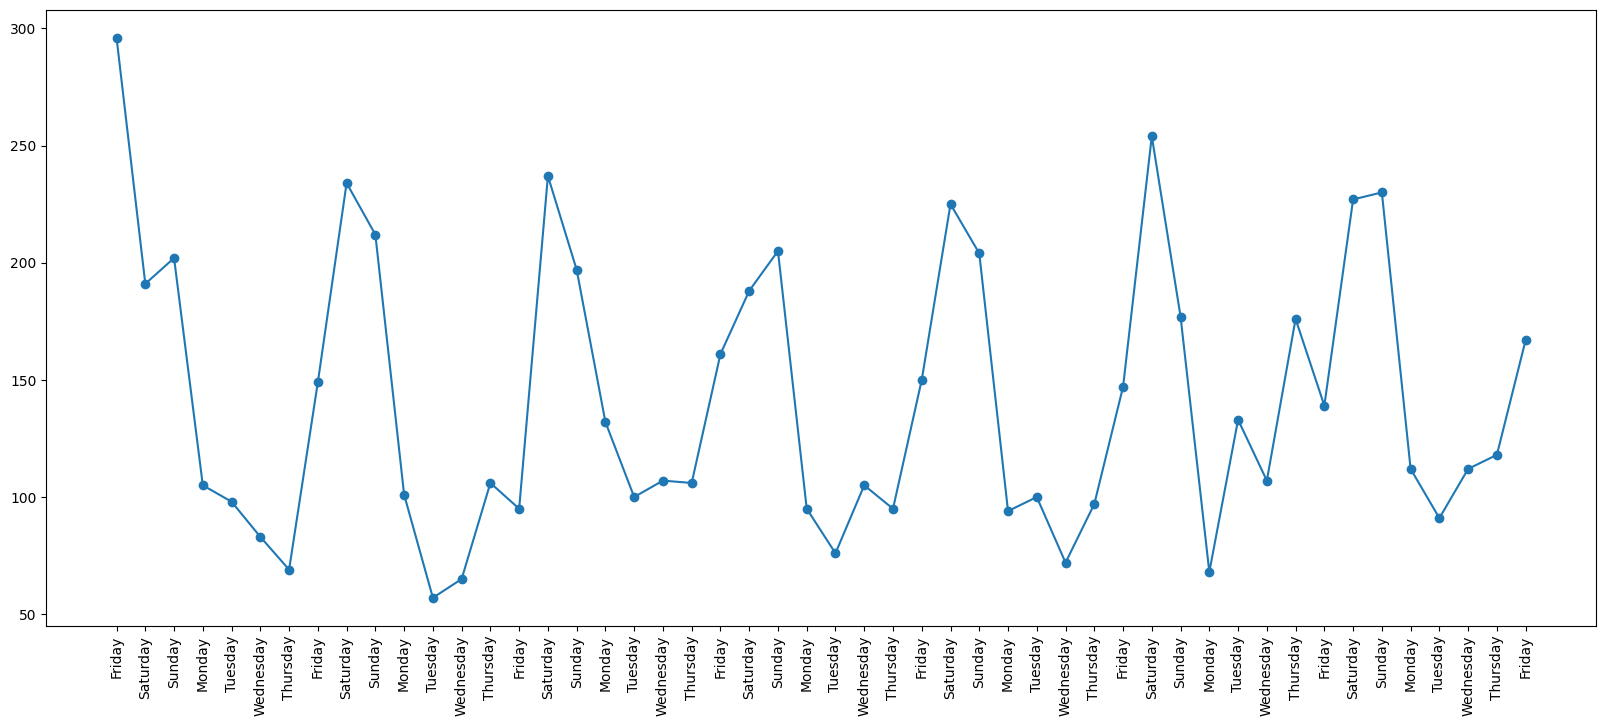

In [ ]:
plt.plot(range(50),df['total'][:50], '-o')
plt.xticks(range(0,50), df['weekday'][:50],rotation = 90)
plt.show()

In [ ]:
df['holiday'].value_counts()


,count
holiday,
0,446
1,32


In [ ]:
holidays = df.loc[df.holiday==1].index

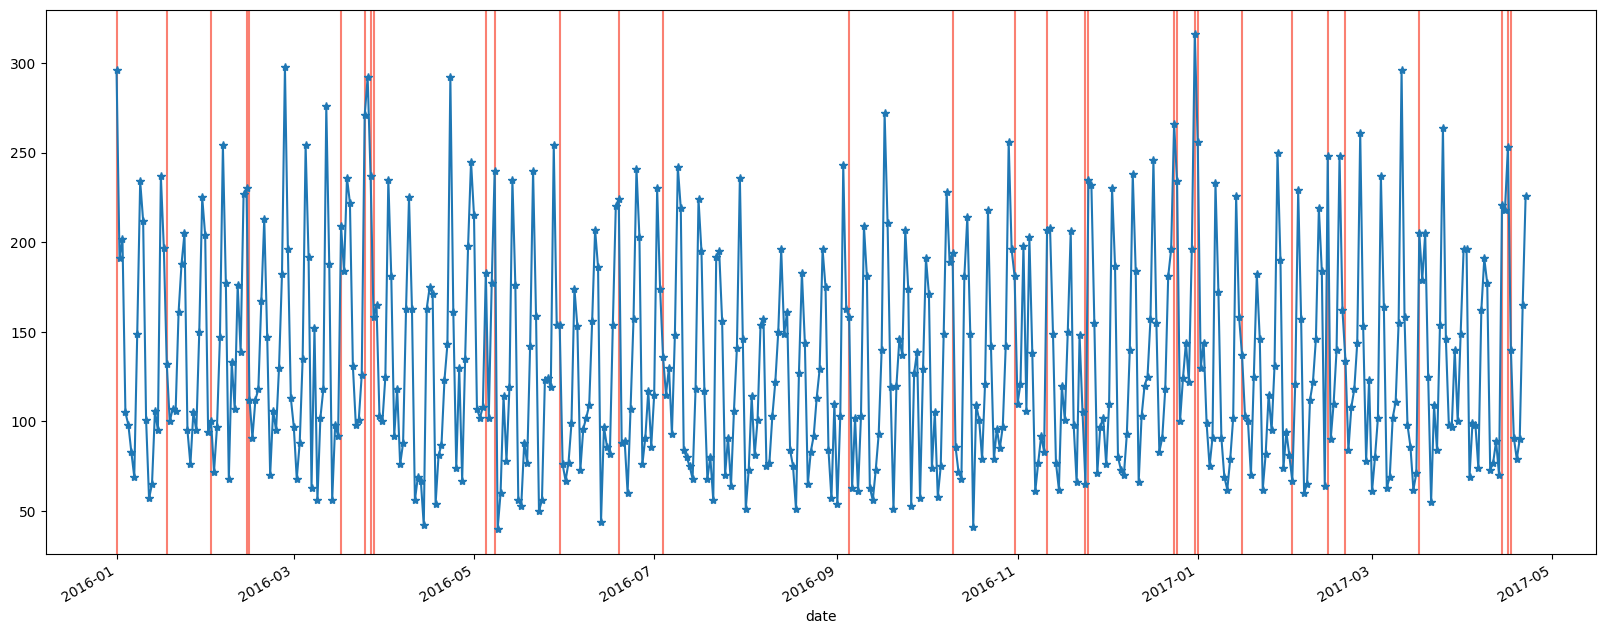

In [ ]:
holidays = df.loc[df.holiday==1].index
for hday in holidays:
    plt.axvline(x=hday, color='#FA8072')
df.total.plot(style='-*')
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose


<Figure size 2000x800 with 0 Axes>

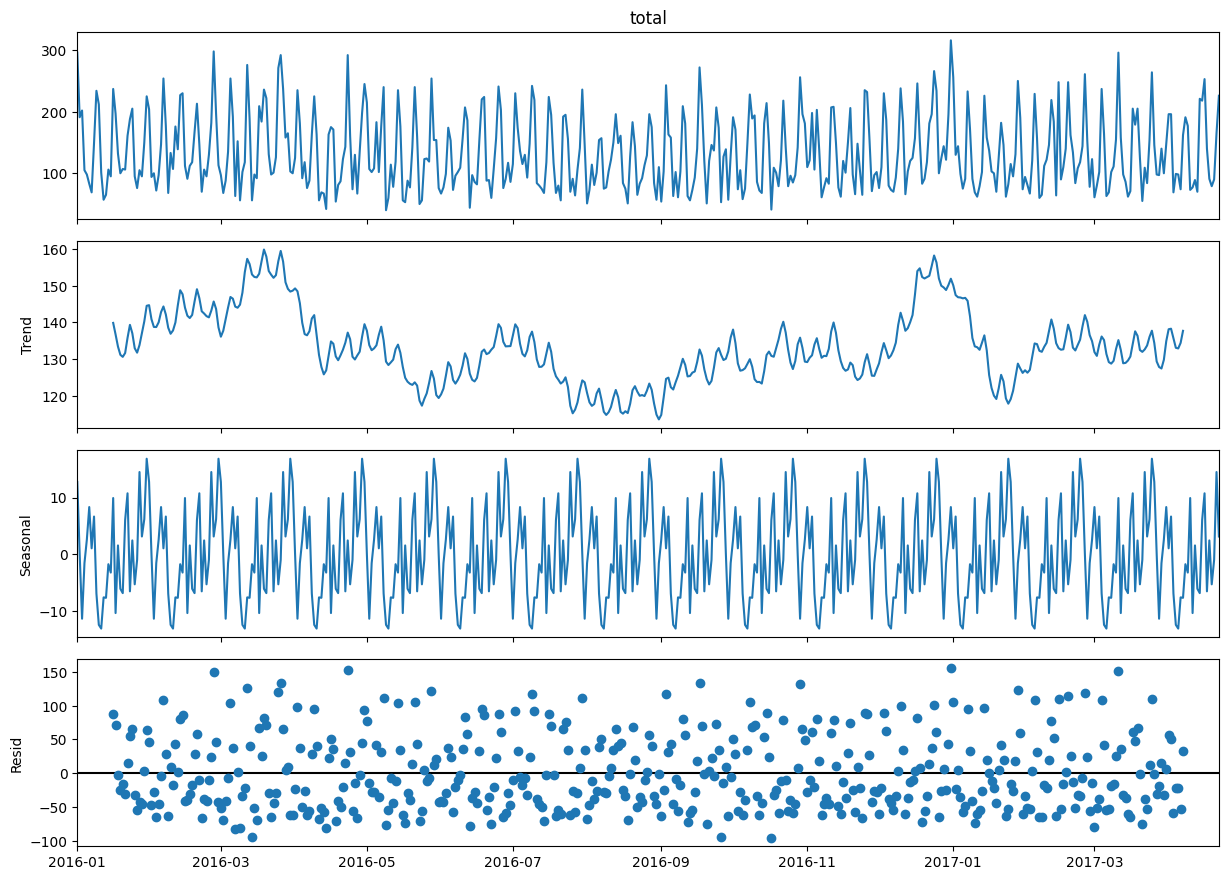

In [ ]:
result = seasonal_decompose(df['total'], model='additive',period = 30)
fig = plt.figure()
fig = result.plot()
fig.set_size_inches(12, 9)
fig.show()

## Fit a SARIMA model on this food chain data

## HW - pmdarima - Library - Helps you get the best order of p,d,q, P,D,Q,s

In [ ]:
## Grid search - Search for min MAPE

In [ ]:
train = df.iloc[:436]
test = df.iloc[436:]

In [ ]:
model = SARIMAX(train['total'],seasonal_order=(1,0,1,7))
results = model.fit()
fc = results.forecast(42)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


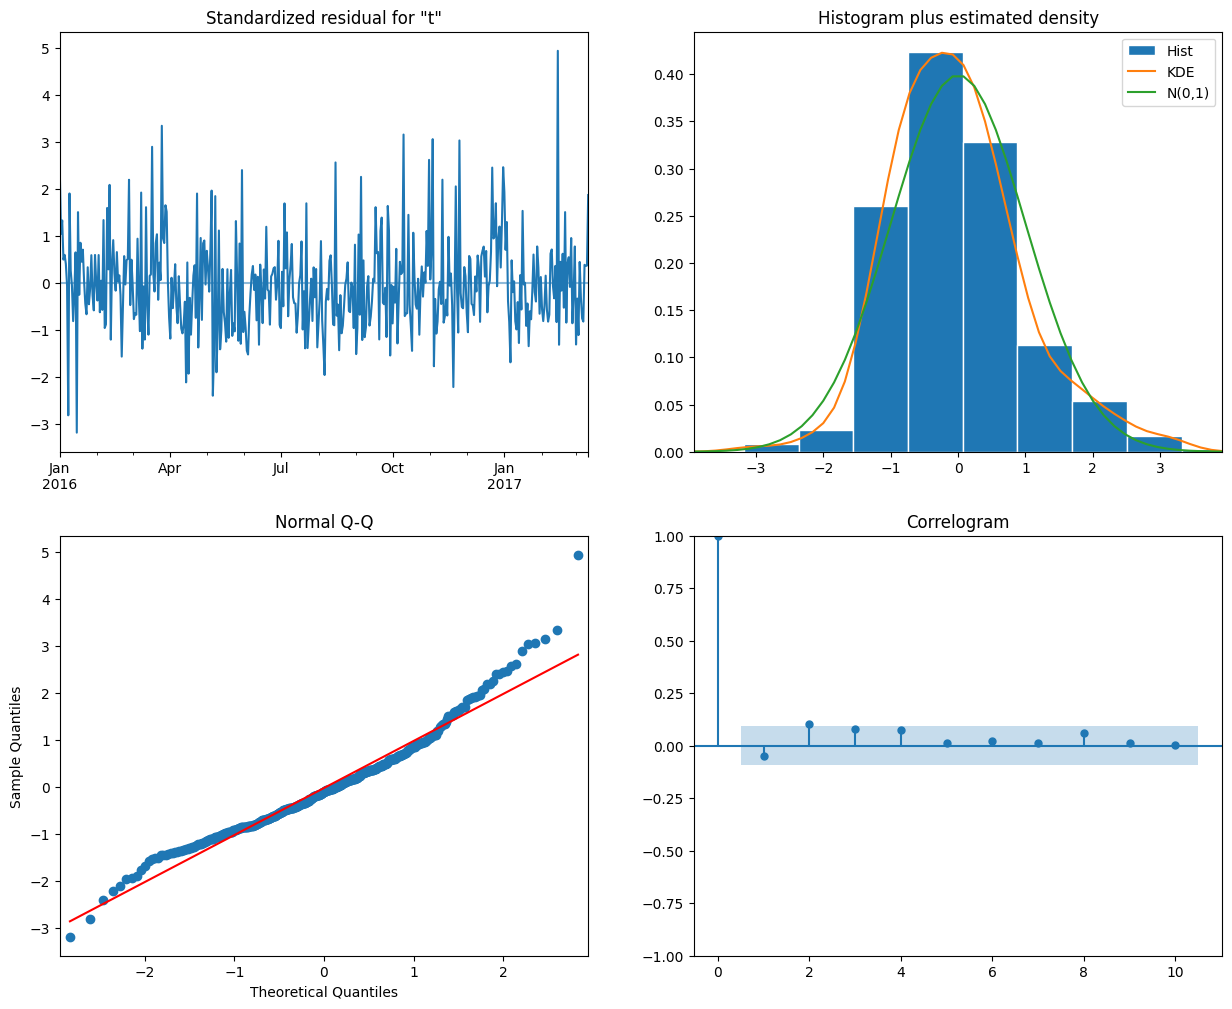

In [ ]:
results.plot_diagnostics(figsize=(15, 12))
plt.show()

In [ ]:
start=len(train)
end=len(train)+len(test)-1
predictions = results.predict(start=start, end=end)

In [ ]:
performance(test['total'], predictions)
# Plot predictions against known values
title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'

MAE : 25.16
RMSE : 31.97
MAPE: 0.202


In [ ]:
## MOdel prediction

## Whether it was a holiday or not

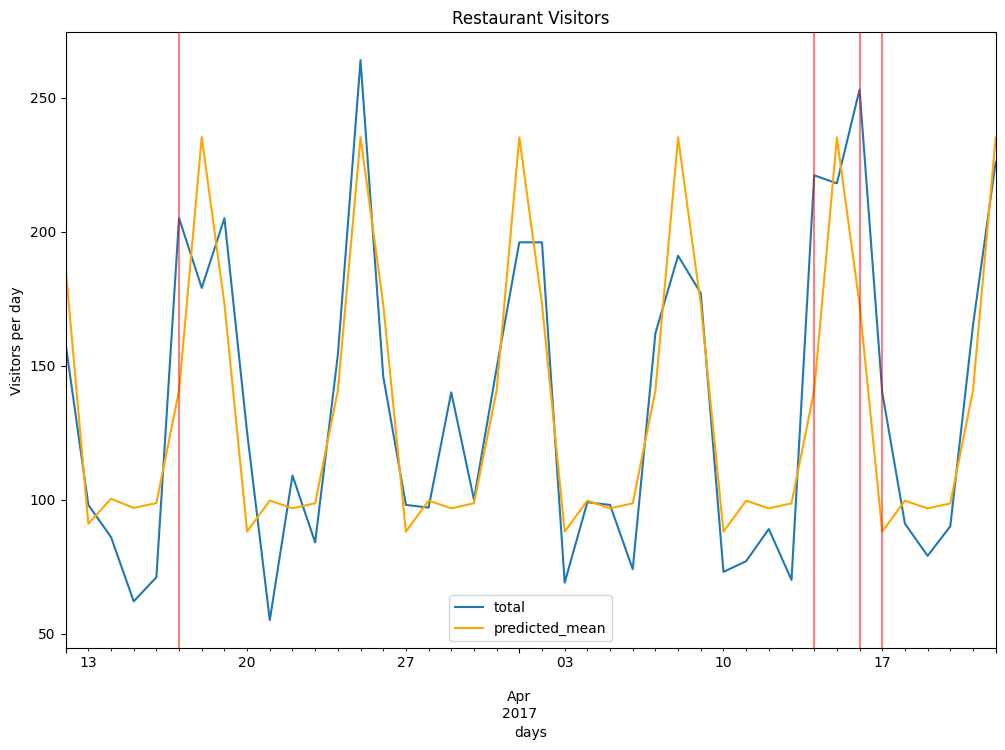

In [ ]:
ax = test['total'].plot(legend=True,figsize=(12,8),title=title)
predictions.plot(legend=True,color = 'orange')
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5)

In [ ]:
train

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0
...,...,...,...
2017-03-07,Tuesday,0,69.0
2017-03-08,Wednesday,0,102.0
2017-03-09,Thursday,0,111.0


In [ ]:
model = SARIMAX(train['total'], exog=train['holiday'], order = (1,0,0), seasonal_order=(1,0,1,7))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:

results = model.fit()


## Forecast

In [ ]:
exog_forecast = test[['holiday']]

In [ ]:
exog_forecast.shape

(42, 1)

In [ ]:
start

436

In [ ]:
predictions = results.predict(start=start, end=end, exog=exog_forecast).rename('Predictions')

In [ ]:
predictions

,Predictions
2017-03-12,181.576481
2017-03-13,80.198341
2017-03-14,96.324219
2017-03-15,96.792807
2017-03-16,93.636217
2017-03-17,206.217231
2017-03-18,230.465473
2017-03-19,167.705146
2017-03-20,77.260803
2017-03-21,95.695903


In [ ]:
performance(test['total'], predictions)

MAE : 18.905
RMSE : 23.265
MAPE: 0.163


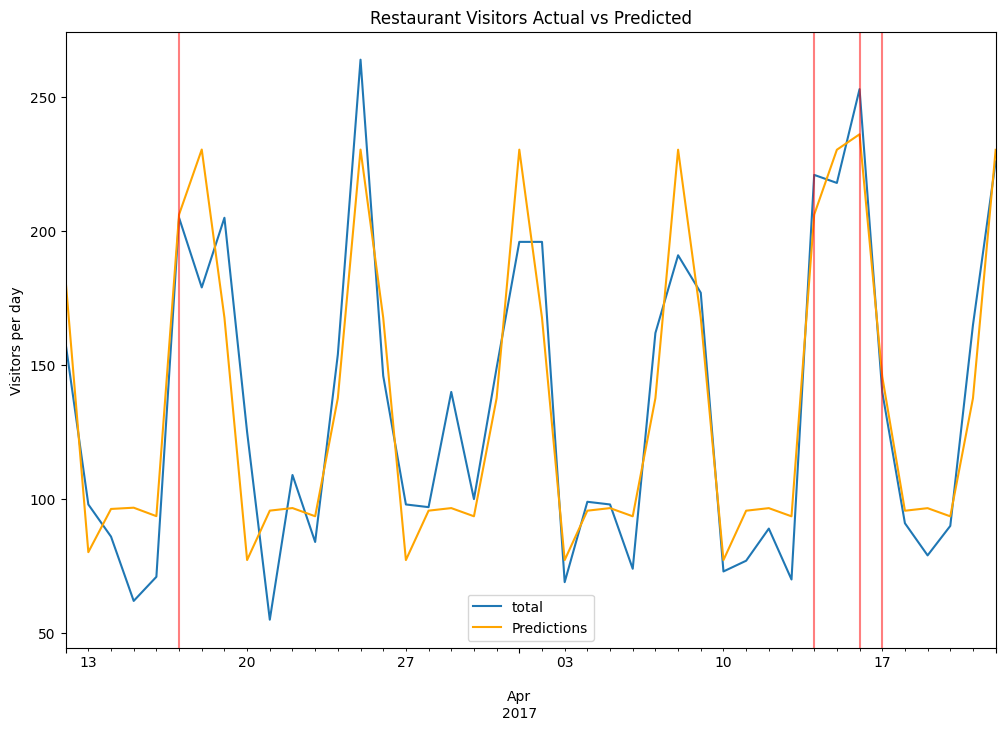

In [ ]:
# Plot predictions against known values
title='Restaurant Visitors Actual vs Predicted'
ylabel='Visitors per day'
xlabel=''

ax = test['total'].plot(legend=True,figsize=(12,8),title=title)
predictions.plot(legend=True, color = 'orange')
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in test.query('holiday==1').index:
    ax.axvline(x=x, color='red', alpha = 0.5);

## Pipeline

In [ ]:
model = SARIMAX(df['total'],exog=df['holiday'],order=(1,0,0),seasonal_order=(1,0,1,7),enforce_invertibility=False)

results = model.fit()

exog_forecast = df1[478:][['holiday']]
fcast = results.predict(478,df1.shape[0]-1,exog = exog_forecast).rename('Forecast')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


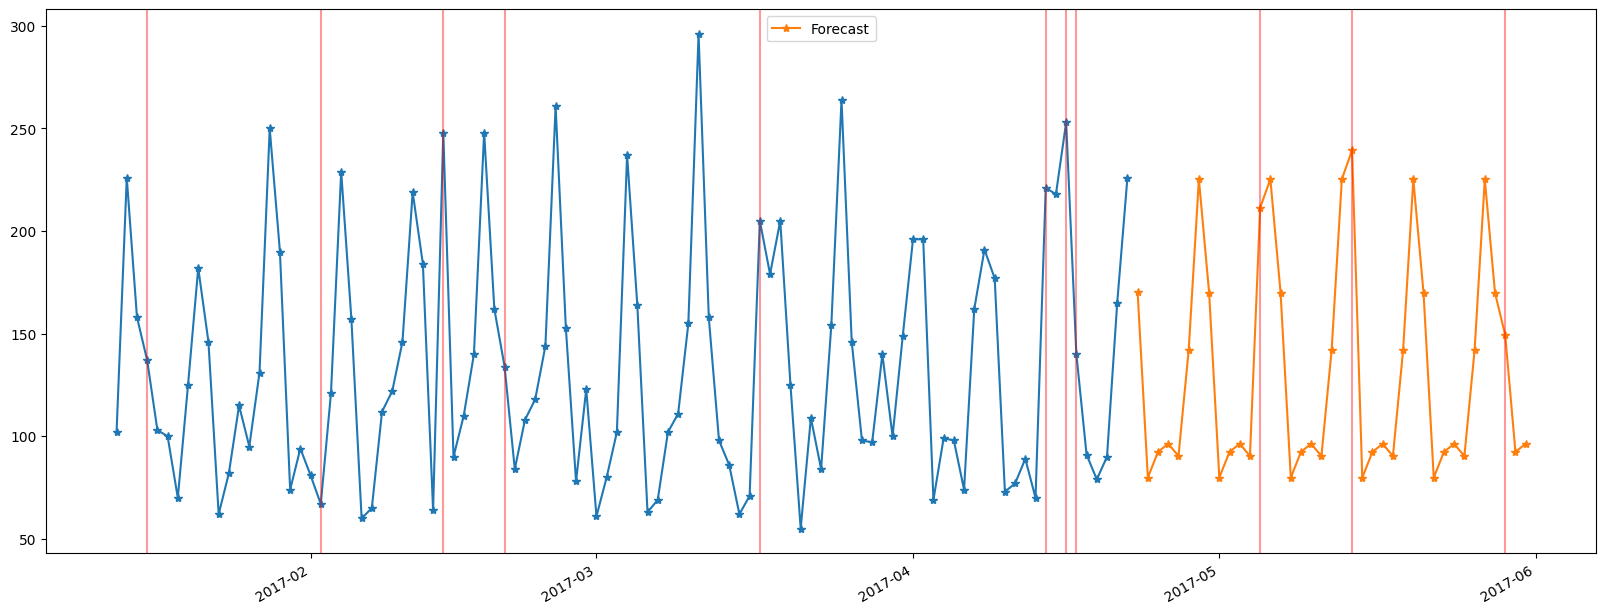

In [ ]:
# Plot the forecast alongside historical values
title='Restaurant Visitors'
ylabel='Visitors per day'
xlabel='days'

# ax = df['total'][-100:].plot(legend=True,figsize=(16,5),title=title, style = '-*')
plt.plot(df[-100:].index, df[-100:].total, '-*')
fcast.plot(legend=True, style = '-*')
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
for x in df[-100:].query('holiday==1').index:
    plt.axvline(x=x, color='red', alpha = 0.4)

for x in df1[-42:].query('holiday==1').date:
    plt.axvline(x=pd.to_datetime(x), color='red', alpha = 0.4)

## Time Series with Linear Regression

In [ ]:
df = df1.copy()
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df

,date,weekday,holiday,total
0,2016-01-01,Friday,1,296.0
1,2016-01-02,Saturday,0,191.0
2,2016-01-03,Sunday,0,202.0
3,2016-01-04,Monday,0,105.0
4,2016-01-05,Tuesday,0,98.0
...,...,...,...,...
512,2017-05-27,Saturday,0,NaN
513,2017-05-28,Sunday,0,NaN
514,2017-05-29,Monday,1,NaN
515,2017-05-30,Tuesday,0,NaN


In [ ]:
df["weekday"] = np.where(((df["weekday"] == "Friday") | (df["weekday"] == "Thursday") | (df["weekday"] == "Wednesday") | (df["weekday"] == "Tuesday") | (df["weekday"] == "Monday")), "working_day", "weekend")

In [ ]:
df

,date,weekday,holiday,total
0,2016-01-01,working_day,1,296.0
1,2016-01-02,weekend,0,191.0
2,2016-01-03,weekend,0,202.0
3,2016-01-04,working_day,0,105.0
4,2016-01-05,working_day,0,98.0
...,...,...,...,...
512,2017-05-27,weekend,0,NaN
513,2017-05-28,weekend,0,NaN
514,2017-05-29,working_day,1,NaN
515,2017-05-30,working_day,0,NaN


In [ ]:
intmdt = pd.get_dummies(df['weekday'])


In [ ]:
intmdt

,weekend,working_day
0,False,True
1,True,False
2,True,False
3,False,True
4,False,True
...,...,...
512,True,False
513,True,False
514,False,True
515,False,True


In [ ]:
df = pd.concat([df, intmdt],axis =1 )

In [ ]:
df

,date,weekday,holiday,total,weekend,working_day
0,2016-01-01,working_day,1,296.0,False,True
1,2016-01-02,weekend,0,191.0,True,False
2,2016-01-03,weekend,0,202.0,True,False
3,2016-01-04,working_day,0,105.0,False,True
4,2016-01-05,working_day,0,98.0,False,True
...,...,...,...,...,...,...
512,2017-05-27,weekend,0,NaN,True,False
513,2017-05-28,weekend,0,NaN,True,False
514,2017-05-29,working_day,1,NaN,False,True
515,2017-05-30,working_day,0,NaN,False,True


In [ ]:
df['total']

,total
0,296.0
1,191.0
2,202.0
3,105.0
4,98.0
...,...
512,NaN
513,NaN
514,NaN
515,NaN


In [ ]:
for i in range(1,32):
  df['lag_{}'.format(i)] = df['total'].shift(i)

In [ ]:
df

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31
0,2016-01-01,working_day,1,296.0,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,weekend,0,191.0,1,0,296.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-03,weekend,0,202.0,1,0,191.0,296.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-04,working_day,0,105.0,0,1,202.0,191.0,296.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-05,working_day,0,98.0,0,1,105.0,202.0,191.0,296.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,2017-05-27,weekend,0,NaN,1,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513,2017-05-28,weekend,0,NaN,1,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
514,2017-05-29,working_day,1,NaN,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,2017-05-30,working_day,0,NaN,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.iloc[29:50]

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31
29,2016-01-30,weekend,0,225.0,1,0,150.0,95.0,105.0,76.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,NaN,NaN
30,2016-01-31,weekend,0,204.0,1,0,225.0,150.0,95.0,105.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,NaN
31,2016-02-01,working_day,0,94.0,0,1,204.0,225.0,150.0,95.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0
32,2016-02-02,working_day,1,100.0,0,1,94.0,204.0,225.0,150.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0
33,2016-02-03,working_day,0,72.0,0,1,100.0,94.0,204.0,225.0,...,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0
34,2016-02-04,working_day,0,97.0,0,1,72.0,100.0,94.0,204.0,...,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0
35,2016-02-05,working_day,0,147.0,0,1,97.0,72.0,100.0,94.0,...,106.0,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0
36,2016-02-06,weekend,0,254.0,1,0,147.0,97.0,72.0,100.0,...,95.0,106.0,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0
37,2016-02-07,weekend,0,177.0,1,0,254.0,147.0,97.0,72.0,...,237.0,95.0,106.0,65.0,57.0,101.0,212.0,234.0,149.0,69.0
38,2016-02-08,working_day,0,68.0,0,1,177.0,254.0,147.0,97.0,...,197.0,237.0,95.0,106.0,65.0,57.0,101.0,212.0,234.0,149.0


In [ ]:
df['weekend'] = df['weekend'].astype(int)
df['working_day'] = df['working_day'].astype(int)


In [ ]:
df

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31
0,2016-01-01,working_day,1,296.0,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,weekend,0,191.0,1,0,296.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-03,weekend,0,202.0,1,0,191.0,296.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-04,working_day,0,105.0,0,1,202.0,191.0,296.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-05,working_day,0,98.0,0,1,105.0,202.0,191.0,296.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,2017-05-27,weekend,0,NaN,1,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513,2017-05-28,weekend,0,NaN,1,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
514,2017-05-29,working_day,1,NaN,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,2017-05-30,working_day,0,NaN,0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
lis = ['lag_{}'.format(i) for i in range(1,32)]

In [ ]:
df.dropna(inplace = True)

In [ ]:
df

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31
31,2016-02-01,working_day,0,94.0,0,1,204.0,225.0,150.0,95.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0
32,2016-02-02,working_day,1,100.0,0,1,94.0,204.0,225.0,150.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0
33,2016-02-03,working_day,0,72.0,0,1,100.0,94.0,204.0,225.0,...,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0
34,2016-02-04,working_day,0,97.0,0,1,72.0,100.0,94.0,204.0,...,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0
35,2016-02-05,working_day,0,147.0,0,1,97.0,72.0,100.0,94.0,...,106.0,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2017-04-18,working_day,0,91.0,0,1,140.0,253.0,218.0,221.0,...,98.0,146.0,264.0,154.0,84.0,109.0,55.0,125.0,205.0,179.0
474,2017-04-19,working_day,0,79.0,0,1,91.0,140.0,253.0,218.0,...,97.0,98.0,146.0,264.0,154.0,84.0,109.0,55.0,125.0,205.0
475,2017-04-20,working_day,0,90.0,0,1,79.0,91.0,140.0,253.0,...,140.0,97.0,98.0,146.0,264.0,154.0,84.0,109.0,55.0,125.0
476,2017-04-21,working_day,0,165.0,0,1,90.0,79.0,91.0,140.0,...,100.0,140.0,97.0,98.0,146.0,264.0,154.0,84.0,109.0,55.0


In [ ]:
lis

['lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'lag_8',
 'lag_9',
 'lag_10',
 'lag_11',
 'lag_12',
 'lag_13',
 'lag_14',
 'lag_15',
 'lag_16',
 'lag_17',
 'lag_18',
 'lag_19',
 'lag_20',
 'lag_21',
 'lag_22',
 'lag_23',
 'lag_24',
 'lag_25',
 'lag_26',
 'lag_27',
 'lag_28',
 'lag_29',
 'lag_30',
 'lag_31']

In [ ]:
lis = ['lag_{}'.format(i) for i in range(1,32)]
df.dropna(inplace = True)    # Drop because some Lags will be NaN.
df['last_month_avg_level'] = df.loc[:,lis].sum(axis=1)/31
df.head()

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,last_month_avg_level
31,2016-02-01,working_day,0,94.0,0,1,204.0,225.0,150.0,95.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355
32,2016-02-02,working_day,1,100.0,0,1,94.0,204.0,225.0,150.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226
33,2016-02-03,working_day,0,72.0,0,1,100.0,94.0,204.0,225.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742
34,2016-02-04,working_day,0,97.0,0,1,72.0,100.0,94.0,204.0,...,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,105.0,129.774194
35,2016-02-05,working_day,0,147.0,0,1,97.0,72.0,100.0,94.0,...,65.0,57.0,101.0,212.0,234.0,149.0,69.0,83.0,98.0,129.516129


In [ ]:
df.columns

Index(['date', 'weekday', 'holiday', 'total', 'weekend', 'working_day',
       'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8',
       'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15',
       'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22',
       'lag_23', 'lag_24', 'lag_25', 'lag_26', 'lag_27', 'lag_28', 'lag_29',
       'lag_30', 'lag_31'],
      dtype='object')

## Biweekly lags

In [ ]:
lis = ["lag_{}".format(i) for i in range(1,15)]
df['last_2week_avg_level'] = df.loc[:,lis].sum(axis = 1)/14
df.head(3)

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,last_month_avg_level,last_2week_avg_level
31,2016-02-01,working_day,0,94.0,0,1,204.0,225.0,150.0,95.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,139.214286
32,2016-02-02,working_day,1,100.0,0,1,94.0,204.0,225.0,150.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,136.500000
33,2016-02-03,working_day,0,72.0,0,1,100.0,94.0,204.0,225.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,136.500000


## Seasonlaity - 7 Days

In [ ]:
df['dayofweek'] = df['date'].dt.dayofweek
df

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,last_month_avg_level,last_2week_avg_level,dayofweek
31,2016-02-01,working_day,0,94.0,0,1,204.0,225.0,150.0,95.0,...,69.0,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,139.214286,0
32,2016-02-02,working_day,1,100.0,0,1,94.0,204.0,225.0,150.0,...,149.0,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,136.500000,1
33,2016-02-03,working_day,0,72.0,0,1,100.0,94.0,204.0,225.0,...,234.0,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,136.500000,2
34,2016-02-04,working_day,0,97.0,0,1,72.0,100.0,94.0,204.0,...,212.0,234.0,149.0,69.0,83.0,98.0,105.0,129.774194,134.000000,3
35,2016-02-05,working_day,0,147.0,0,1,97.0,72.0,100.0,94.0,...,101.0,212.0,234.0,149.0,69.0,83.0,98.0,129.516129,133.357143,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2017-04-18,working_day,0,91.0,0,1,140.0,253.0,218.0,221.0,...,154.0,84.0,109.0,55.0,125.0,205.0,179.0,138.967742,138.714286,1
474,2017-04-19,working_day,0,79.0,0,1,91.0,140.0,253.0,218.0,...,264.0,154.0,84.0,109.0,55.0,125.0,205.0,136.129032,138.142857,2
475,2017-04-20,working_day,0,90.0,0,1,79.0,91.0,140.0,253.0,...,146.0,264.0,154.0,84.0,109.0,55.0,125.0,132.064516,136.785714,3
476,2017-04-21,working_day,0,165.0,0,1,90.0,79.0,91.0,140.0,...,98.0,146.0,264.0,154.0,84.0,109.0,55.0,130.935484,137.928571,4


In [ ]:
df['sale_wrt_dow'] = df.groupby('dayofweek')['total'].transform('mean')

In [ ]:
df

,date,weekday,holiday,total,weekend,working_day,lag_1,lag_2,lag_3,lag_4,...,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,last_month_avg_level,last_2week_avg_level,dayofweek,sale_wrt_dow
31,2016-02-01,working_day,0,94.0,0,1,204.0,225.0,150.0,95.0,...,83.0,98.0,105.0,202.0,191.0,296.0,143.419355,139.214286,0,89.593750
32,2016-02-02,working_day,1,100.0,0,1,94.0,204.0,225.0,150.0,...,69.0,83.0,98.0,105.0,202.0,191.0,136.903226,136.500000,1,94.531250
33,2016-02-03,working_day,0,72.0,0,1,100.0,94.0,204.0,225.0,...,149.0,69.0,83.0,98.0,105.0,202.0,133.967742,136.500000,2,94.687500
34,2016-02-04,working_day,0,97.0,0,1,72.0,100.0,94.0,204.0,...,234.0,149.0,69.0,83.0,98.0,105.0,129.774194,134.000000,3,99.015625
35,2016-02-05,working_day,0,147.0,0,1,97.0,72.0,100.0,94.0,...,212.0,234.0,149.0,69.0,83.0,98.0,129.516129,133.357143,4,147.171875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,2017-04-18,working_day,0,91.0,0,1,140.0,253.0,218.0,221.0,...,84.0,109.0,55.0,125.0,205.0,179.0,138.967742,138.714286,1,94.531250
474,2017-04-19,working_day,0,79.0,0,1,91.0,140.0,253.0,218.0,...,154.0,84.0,109.0,55.0,125.0,205.0,136.129032,138.142857,2,94.687500
475,2017-04-20,working_day,0,90.0,0,1,79.0,91.0,140.0,253.0,...,264.0,154.0,84.0,109.0,55.0,125.0,132.064516,136.785714,3,99.015625
476,2017-04-21,working_day,0,165.0,0,1,90.0,79.0,91.0,140.0,...,146.0,264.0,154.0,84.0,109.0,55.0,130.935484,137.928571,4,147.171875


In [ ]:
df.columns

Index(['date', 'weekday', 'holiday', 'total', 'weekend', 'working_day',
       'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8',
       'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15',
       'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22',
       'lag_23', 'lag_24', 'lag_25', 'lag_26', 'lag_27', 'lag_28', 'lag_29',
       'lag_30', 'lag_31', 'last_month_avg_level', 'last_2week_avg_level',
       'dayofweek', 'sale_wrt_dow'],
      dtype='object')

In [ ]:
import copy             #dfo has the data with all the columns
dfo = df.copy()

In [ ]:
df = dfo.copy()
df = df[['total', 'lag_1', 'last_month_avg_level',
          'last_2week_avg_level', 'sale_wrt_dow', 'holiday']]
df.head()

,total,lag_1,last_month_avg_level,last_2week_avg_level,sale_wrt_dow,holiday
31,94.0,204.0,143.419355,139.214286,89.593750,0
32,100.0,94.0,136.903226,136.500000,94.531250,1
33,72.0,100.0,133.967742,136.500000,94.687500,0
34,97.0,72.0,129.774194,134.000000,99.015625,0
35,147.0,97.0,129.516129,133.357143,147.171875,0


In [ ]:
train = df.iloc[:df.shape[0]-42].dropna()

test = df.iloc[df.shape[0]-42:]

In [ ]:
train_X = train.drop(["total"],axis =1)
train_y = train['total']
test_X = test.drop(["total"],axis =1)
test_y = test['total']

In [ ]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_percentage_error as mape

In [ ]:
# Train and pred
model = LinearRegression()

model.fit(train_X, train_y)

LinearRegression()

In [ ]:
y_pred = pd.Series(model.predict(test_X), index=test.index)
mape(test['total'],y_pred)

0.1476168369463656

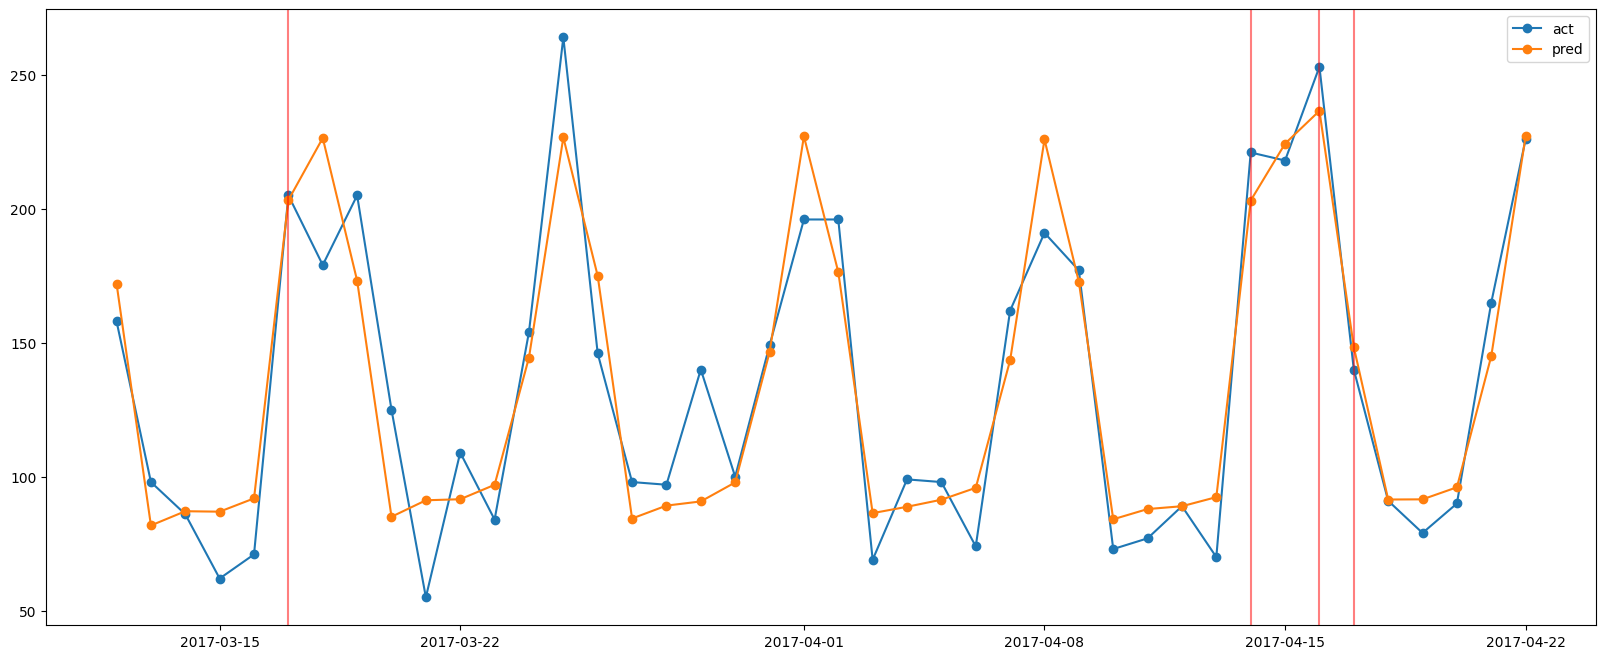

In [ ]:
plt.plot(dfo.tail(42)['date'], test_y, '-o', label='act')
plt.plot(dfo.tail(42)['date'], y_pred, '-o', label='pred')
for x in dfo[-42:].query('holiday==1')['date']:
    plt.axvline(x=x, color='red', alpha = 0.5)
plt.legend()

## Prophet

In [ ]:
df = df1.copy()

In [ ]:
df['ds'] = pd.to_datetime(df['date'])

In [ ]:
df['y'] = df['total']

In [ ]:
df = df[['ds', 'y', 'holiday']]

In [ ]:
df

,ds,y,holiday
0,2016-01-01,296.0,1
1,2016-01-02,191.0,0
2,2016-01-03,202.0,0
3,2016-01-04,105.0,0
4,2016-01-05,98.0,0
...,...,...,...
512,2017-05-27,NaN,0
513,2017-05-28,NaN,0
514,2017-05-29,NaN,1
515,2017-05-30,NaN,0


In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

# initialize model
m = Prophet()

In [ ]:
m.fit(df[['ds', 'y']][:-39])

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = m.make_future_dataframe(periods=39, freq='D')

In [ ]:
future

,ds
0,2016-01-01
1,2016-01-02
2,2016-01-03
3,2016-01-04
4,2016-01-05
...,...
512,2017-05-27
513,2017-05-28
514,2017-05-29
515,2017-05-30


In [ ]:
forecast = m.predict(future)

In [ ]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-01-01,143.063792,117.693715,199.798029,143.063792,143.063792,15.210154,15.210154,15.210154,15.210154,15.210154,15.210154,0.0,0.0,0.0,158.273947
1,2016-01-02,142.991504,194.966897,281.904654,142.991504,142.991504,94.493931,94.493931,94.493931,94.493931,94.493931,94.493931,0.0,0.0,0.0,237.485435
2,2016-01-03,142.919215,148.737391,228.935094,142.919215,142.919215,46.765640,46.765640,46.765640,46.765640,46.765640,46.765640,0.0,0.0,0.0,189.684855
3,2016-01-04,142.846927,58.856356,138.129927,142.846927,142.846927,-42.866582,-42.866582,-42.866582,-42.866582,-42.866582,-42.866582,0.0,0.0,0.0,99.980345
4,2016-01-05,142.774638,61.756349,143.411803,142.774638,142.774638,-39.702846,-39.702846,-39.702846,-39.702846,-39.702846,-39.702846,0.0,0.0,0.0,103.071793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,2017-05-27,136.333165,189.324692,271.358463,136.181558,136.491991,94.493931,94.493931,94.493931,94.493931,94.493931,94.493931,0.0,0.0,0.0,230.827096
513,2017-05-28,136.358874,141.694437,225.008867,136.202695,136.526004,46.765640,46.765640,46.765640,46.765640,46.765640,46.765640,0.0,0.0,0.0,183.124513
514,2017-05-29,136.384583,52.630718,136.058618,136.220591,136.559432,-42.866582,-42.866582,-42.866582,-42.866582,-42.866582,-42.866582,0.0,0.0,0.0,93.518001
515,2017-05-30,136.410292,55.810996,133.744357,136.235333,136.591564,-39.702846,-39.702846,-39.702846,-39.702846,-39.702846,-39.702846,0.0,0.0,0.0,96.707446


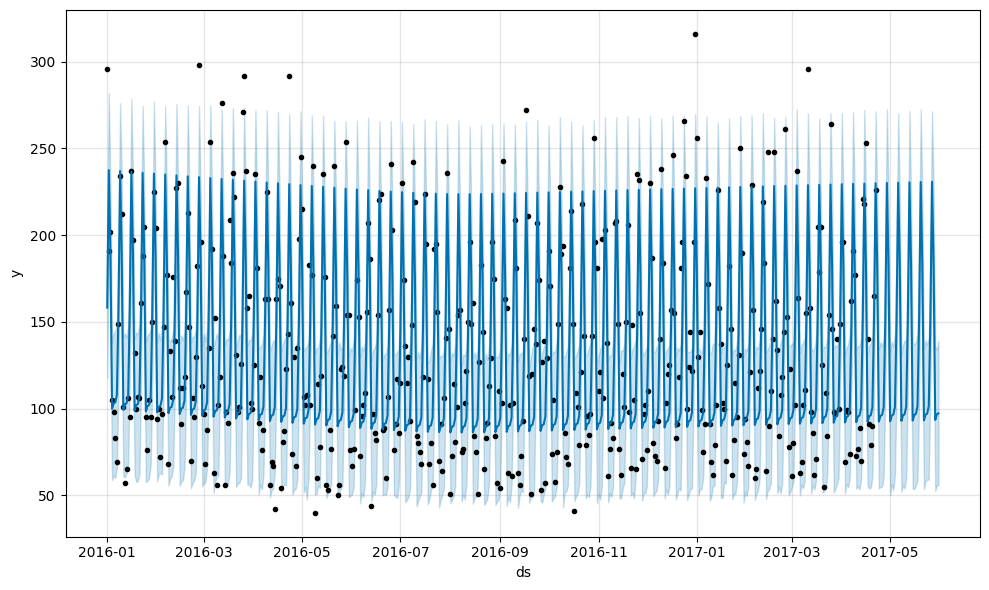

In [ ]:
fig = m.plot(forecast)

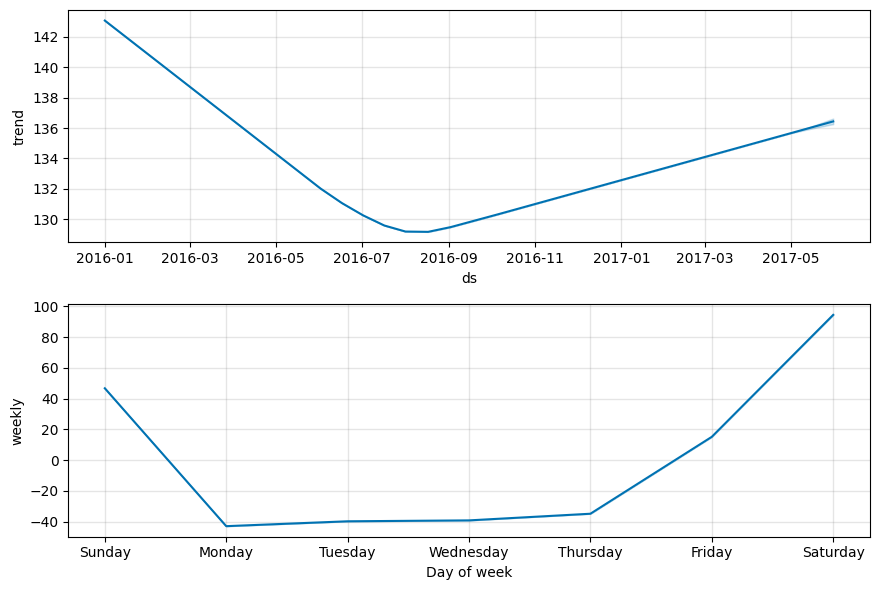

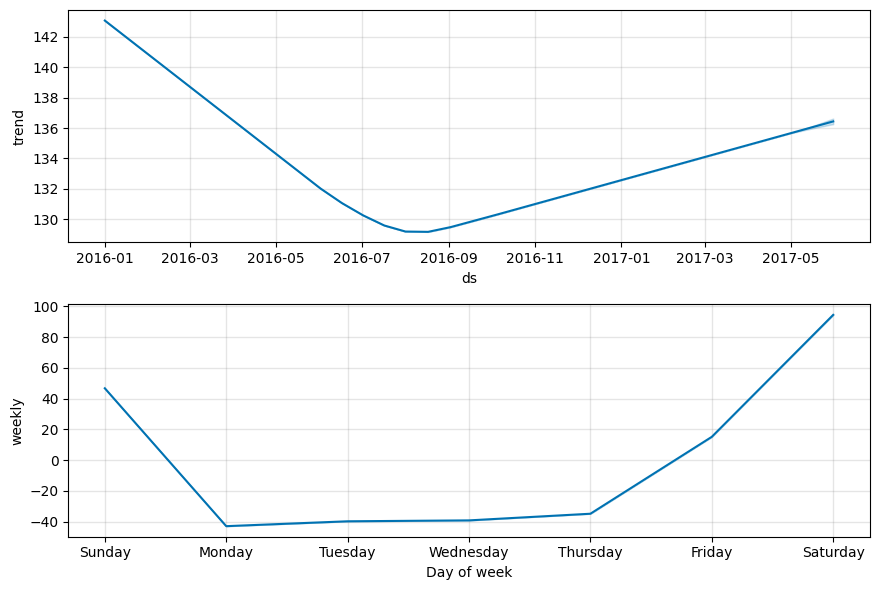

In [ ]:
m.plot_components(forecast)

In [ ]:
performance(df['y'][:-39],forecast['yhat'][:-39])

MAE : 24.057
RMSE : 31.984
MAPE: 0.213


## Multiple Seasonality

In [ ]:
from prophet import Prophet

model2 = Prophet(
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=4
)

In [ ]:
model2.add_regressor('holiday')

In [ ]:
model2.fit(df[:-39])

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
forecast2 = model2.predict(df)

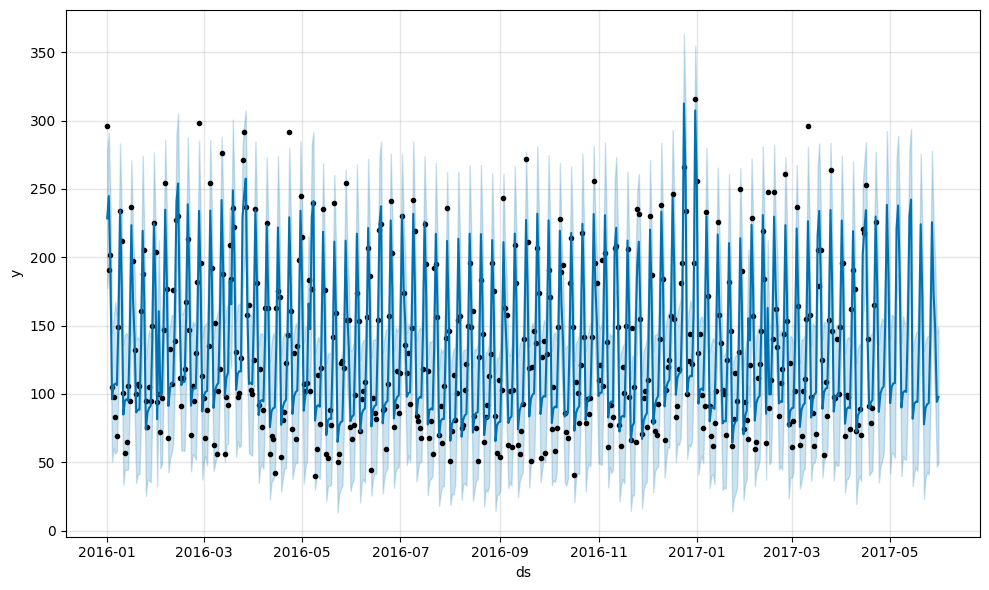

In [ ]:
fig = model2.plot(forecast2)

In [ ]:
performance(df['y'][:-39],forecast2['yhat'][:-39])

MAE : 19.923
RMSE : 25.671
MAPE: 0.18


In [ ]:
from prophet import Prophet

model3 = Prophet(
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=4
)

In [ ]:
model3.add_country_holidays(country_name='US')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


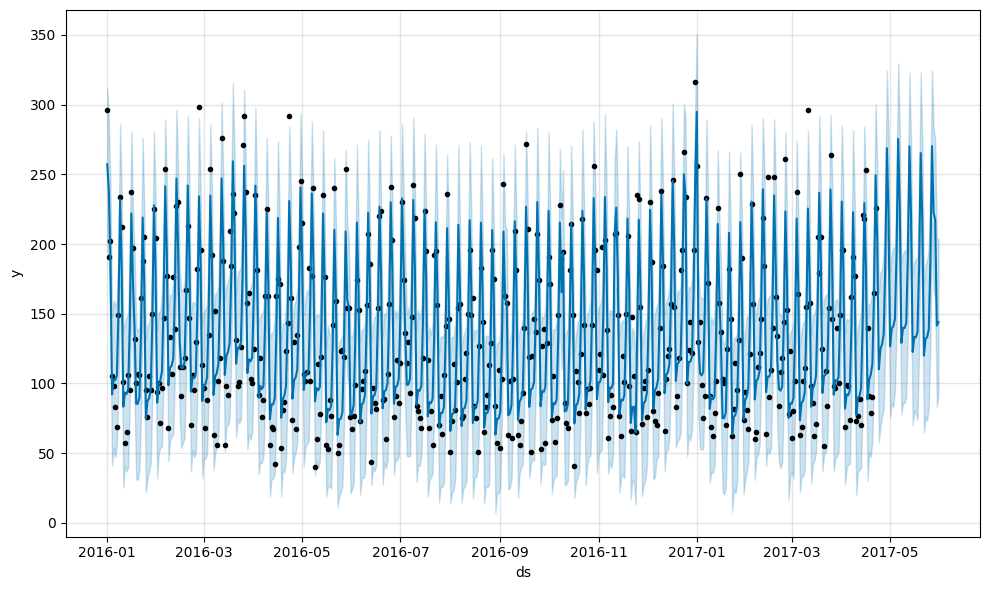

In [ ]:
model3.add_country_holidays(country_name='US')

# fit model (leave last 39 points)
model3.fit(df[:-39])

# create future dataframe FROM THE SAME MODEL
future = model3.make_future_dataframe(periods=39, freq='D')

# forecast on future
forecast3 = model3.predict(future)

# plot forecast
fig = model3.plot(forecast3)

In [ ]:
performance(df['y'][:-39],forecast3['yhat'][:-39])

MAE : 20.942
RMSE : 27.732
MAPE: 0.184


[[<matplotlib.lines.Line2D at 0x7a2c2e4d5f70>],

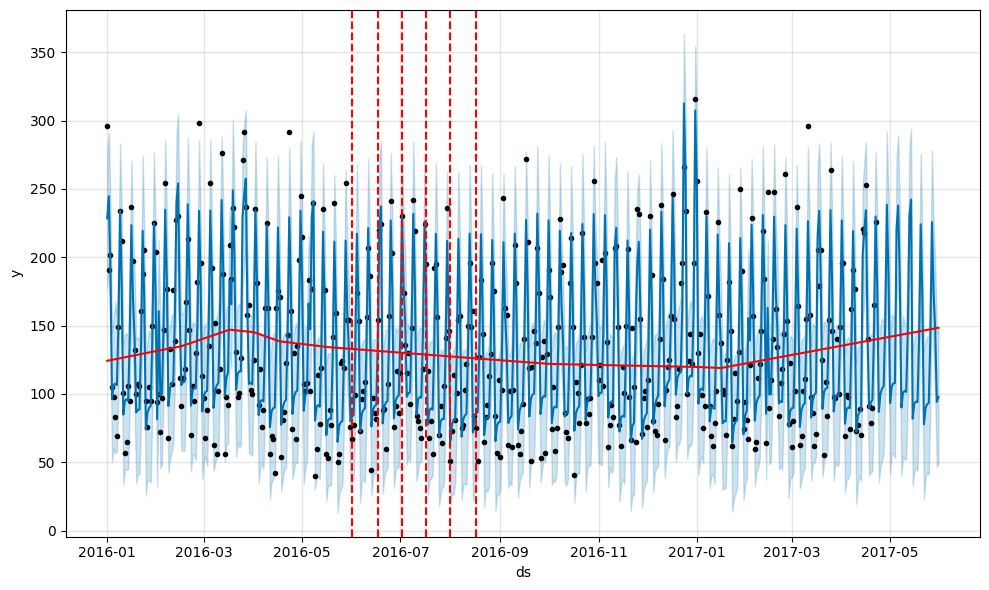

In [ ]:
from prophet.plot import add_changepoints_to_plot

fig = m.plot(forecast2)
add_changepoints_to_plot(fig.gca(), m, forecast2)